# Week 1 — Exploratory Data Analysis
Instacart Market Basket Analysis — 6 source CSVs.

**Goal**: Understand data shape, distributions, join keys, and reorder patterns before building the pipeline.

In [14]:
import argparse
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PURPLE = "#534AB7"
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
GRAY   = "#888780"

# Parse args when run as script; use defaults in notebook mode
parser = argparse.ArgumentParser()
parser.add_argument("--data-dir", default="./data/raw")
parser.add_argument("--save-figs", action="store_true")
args, _ = parser.parse_known_args()

DATA_DIR = Path(args.data_dir)
FIG_DIR  = Path("notebooks/figures")
if args.save_figs:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str):
    if args.save_figs:
        p = FIG_DIR / f"{name}.png"
        plt.savefig(p, dpi=150, bbox_inches="tight")
        print(f"  Saved {p}")

##  1. Load data

In [15]:
print("Loading CSV files ...")
orders = pd.read_csv(DATA_DIR / "orders.csv")
prior = pd.read_csv(DATA_DIR / "order_products__prior.csv")
train = pd.read_csv(DATA_DIR / "order_products__train.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
aisles = pd.read_csv(DATA_DIR / "aisles.csv")
departments = pd.read_csv(DATA_DIR / "departments.csv")

print(f"\nDataset sizes:")
print(f"  orders:               {len(orders):>12,}  rows")
print(f"  order_products_prior: {len(prior):>12,}  rows")
print(f"  order_products_train: {len(train):>12,}  rows")
print(f"  products:             {len(products):>12,}  rows")
print(f"  aisles:               {len(aisles):>12,}  rows")
print(f"  departments:          {len(departments):>12,}  rows")
print(f"\nUnique users:    {orders['user_id'].nunique():,}")
print(f"Unique products: {products['product_id'].nunique():,}")

Loading CSV files ...

Dataset sizes:
  orders:                  3,421,083  rows
  order_products_prior:   32,434,489  rows
  order_products_train:    1,384,617  rows
  products:                   49,688  rows
  aisles:                        134  rows
  departments:                    21  rows

Unique users:    206,209
Unique products: 49,688


## 2. Task A — Reorder Rate (Label Balance)


Reorder rate (prior): 0.590  (59.0%)
Reorder rate (train): 0.599  (59.9%)

Class balance (train):
reordered
reordered        0.598594
not reordered    0.401406
Name: proportion, dtype: float64


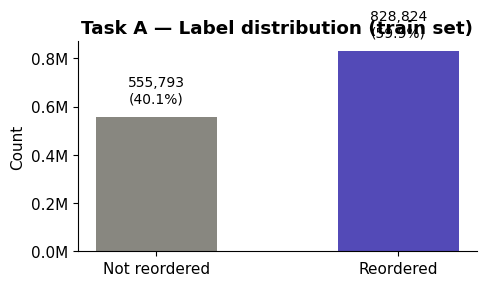

In [16]:
reorder_rate_prior = prior["reordered"].mean()
reorder_rate_train = train["reordered"].mean()

print(f"\nReorder rate (prior): {reorder_rate_prior:.3f}  ({reorder_rate_prior*100:.1f}%)")
print(f"Reorder rate (train): {reorder_rate_train:.3f}  ({reorder_rate_train*100:.1f}%)")
print(f"\nClass balance (train):")
print(train["reordered"].value_counts(normalize=True).rename({0: "not reordered", 1: "reordered"}))

fig, ax = plt.subplots(figsize=(5, 3))
labels = ["Not reordered", "Reordered"]
values = train["reordered"].value_counts().sort_index().values
colors = [GRAY, PURPLE]
bars = ax.bar(labels, values, color=colors, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50_000,
            f"{val:,}\n({val/len(train)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Task A — Label distribution (train set)", fontweight="bold")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
savefig("01_label_balance")
plt.show()

## 3. User Behaviour — Order Frequency


Orders per user:
count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000


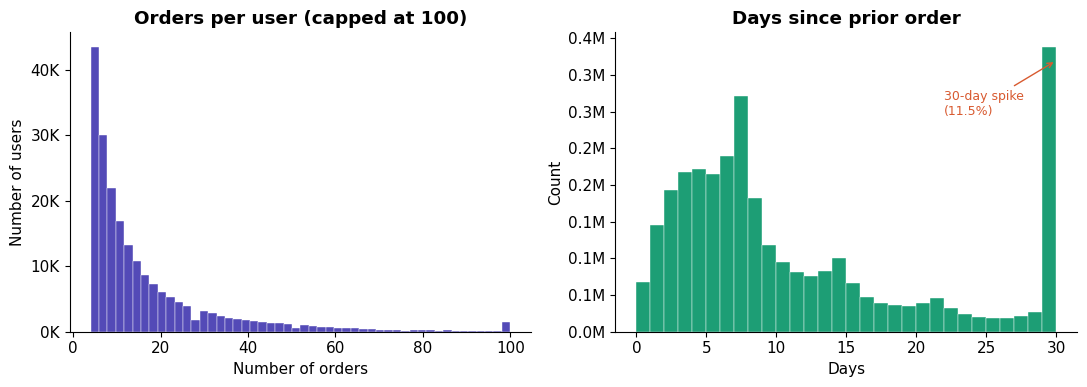

In [17]:
orders_per_user = orders.groupby("user_id")["order_number"].max()

print(f"\nOrders per user:")
print(orders_per_user.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Distribution (capped at 100)
axes[0].hist(orders_per_user.clip(upper=100), bins=50, color=PURPLE, edgecolor="white", linewidth=0.3)
axes[0].set_title("Orders per user (capped at 100)", fontweight="bold")
axes[0].set_xlabel("Number of orders")
axes[0].set_ylabel("Number of users")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

# Days since prior order
valid_gaps = orders["days_since_prior_order"].dropna()
axes[1].hist(valid_gaps, bins=30, color=TEAL, edgecolor="white", linewidth=0.3)
axes[1].set_title("Days since prior order", fontweight="bold")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Highlight 30-day spike (monthly shoppers)
peak_30 = (valid_gaps == 30).sum()
axes[1].annotate(f"30-day spike\n({peak_30/len(valid_gaps)*100:.1f}%)",
                 xy=(30, peak_30), xytext=(22, peak_30 * 0.8),
                 arrowprops=dict(arrowstyle="->", color=CORAL),
                 color=CORAL, fontsize=9)

plt.tight_layout()
savefig("02_user_behaviour")
plt.show()

## 4. Basket Size Distribution


Basket size (prior orders):
count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02


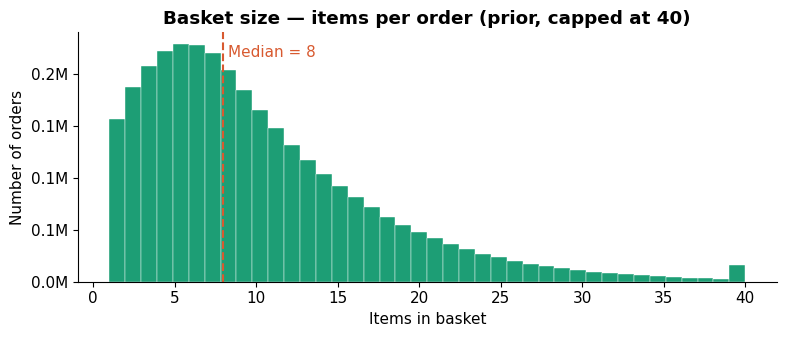

In [18]:
basket_size = prior.groupby("order_id").size()
print(f"\nBasket size (prior orders):")
print(basket_size.describe().to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(basket_size.clip(upper=40), bins=40, color=TEAL, edgecolor="white", linewidth=0.3)
ax.set_title("Basket size — items per order (prior, capped at 40)", fontweight="bold")
ax.set_xlabel("Items in basket")
ax.set_ylabel("Number of orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
median_bs = basket_size.median()
ax.axvline(median_bs, color=CORAL, linewidth=1.5, linestyle="--")
ax.text(median_bs + 0.3, ax.get_ylim()[1] * 0.9, f"Median = {median_bs:.0f}", color=CORAL)
plt.tight_layout()
savefig("03_basket_size")
plt.show()

## 5. Time Patterns

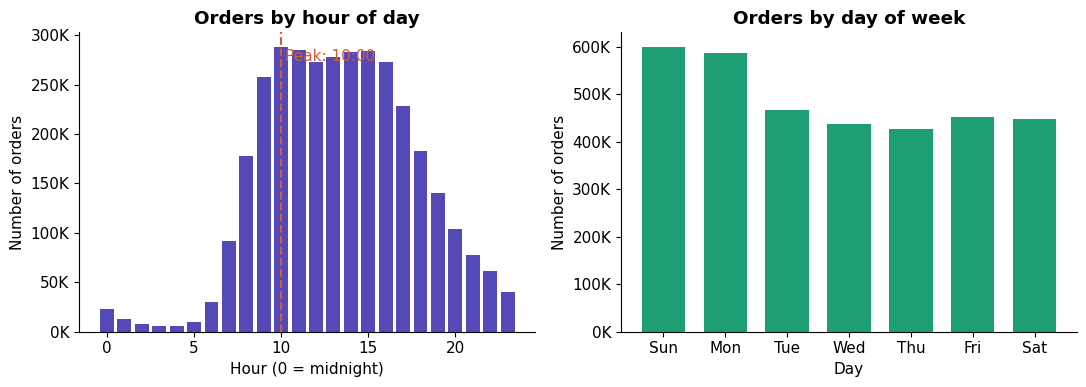

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Orders by hour of day
hour_counts = orders["order_hour_of_day"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color=PURPLE, width=0.8)
axes[0].set_title("Orders by hour of day", fontweight="bold")
axes[0].set_xlabel("Hour (0 = midnight)")
axes[0].set_ylabel("Number of orders")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
peak_hour = hour_counts.idxmax()
axes[0].axvline(peak_hour, color=CORAL, linewidth=1.5, linestyle="--")
axes[0].text(peak_hour + 0.2, hour_counts.max() * 0.95, f"Peak: {peak_hour}:00", color=CORAL)

# Orders by day of week
dow_counts = orders["order_dow"].value_counts().sort_index()
dow_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
axes[1].bar(dow_labels, dow_counts.values, color=TEAL, width=0.7)
axes[1].set_title("Orders by day of week", fontweight="bold")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Number of orders")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.tight_layout()
savefig("04_time_patterns")
plt.show()

## 6. Product Long-Tail (Task B — Cold Start Risk)


Product popularity (prior orders):
  Total unique products purchased: 49,677
  Top 4,537 products (9.1%) drive 80% of purchases
  Products never purchased in prior: 11 (0.0%)


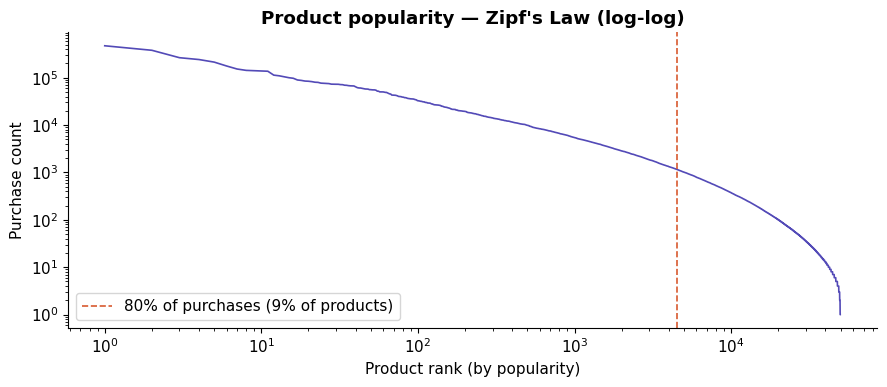

In [20]:
product_counts = prior.groupby("product_id").size().sort_values(ascending=False).reset_index()
product_counts.columns = ["product_id", "purchase_count"]

total_products = len(product_counts)
total_purchases = product_counts["purchase_count"].sum()

# What fraction of products cover 80% of purchases?
cumsum = product_counts["purchase_count"].cumsum() / total_purchases
n_80pct = (cumsum <= 0.80).sum()
pct_products = n_80pct / total_products * 100

print(f"\nProduct popularity (prior orders):")
print(f"  Total unique products purchased: {total_products:,}")
print(f"  Top {n_80pct:,} products ({pct_products:.1f}%) drive 80% of purchases")
print(f"  Products never purchased in prior: "
      f"{len(products) - total_products:,} "
      f"({(len(products)-total_products)/len(products)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 4))
ranks = np.arange(1, len(product_counts) + 1)
ax.loglog(ranks, product_counts["purchase_count"].values, color=PURPLE, linewidth=1.2)
ax.axvline(n_80pct, color=CORAL, linewidth=1.2, linestyle="--",
           label=f"80% of purchases ({pct_products:.0f}% of products)")
ax.set_title("Product popularity — Zipf's Law (log-log)", fontweight="bold")
ax.set_xlabel("Product rank (by popularity)")
ax.set_ylabel("Purchase count")
ax.legend()
plt.tight_layout()
savefig("05_product_longtail")
plt.show()

## 7. Top Departments (Source 2 preview)

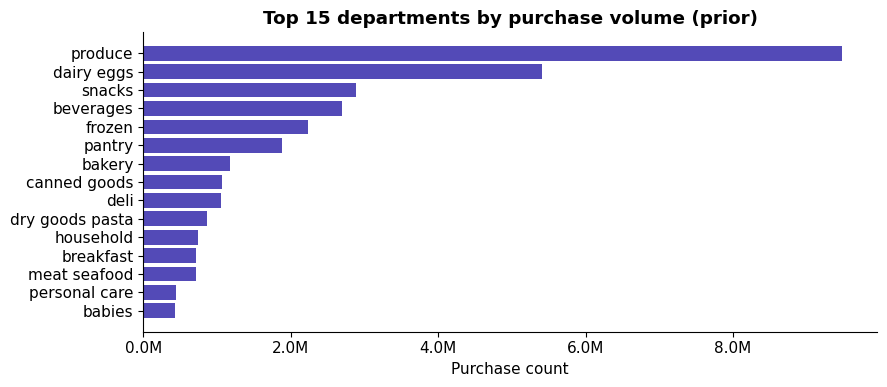

In [21]:
products_full = (
    products
    .merge(aisles, on="aisle_id")
    .merge(departments, on="department_id")
)

dept_counts = (
    prior
    .merge(products_full[["product_id", "department"]], on="product_id")
    .groupby("department").size()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(dept_counts.index[::-1], dept_counts.values[::-1], color=PURPLE)
ax.set_title("Top 15 departments by purchase volume (prior)", fontweight="bold")
ax.set_xlabel("Purchase count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
savefig("06_top_departments")
plt.show()

## 8. Key Findings Summary

In [22]:
print("\n" + "="*60)
print("KEY FINDINGS FOR ML PIPELINE")
print("="*60)

print(f"""
Task A — Reorder Prediction:
  • Reorder rate: {reorder_rate_train*100:.1f}% — imbalanced labels
    → Use class_weight='balanced' or scale_pos_weight in LightGBM
  • days_since_prior_order: median={valid_gaps.median():.0f}d, 30-day spike ({peak_30/len(valid_gaps)*100:.1f}%)
    → Most important single feature for reorder prediction
  • Users average {orders_per_user.mean():.0f} orders — good history depth for features

Task B — Recommendation:
  • Top {pct_products:.0f}% of products drive 80% of purchases — severe long tail
    → ALS will have weak embeddings for tail products
    → Content-Based (Source 2) essential to fill cold-start gap
  • {(len(products)-total_products)/len(products)*100:.1f}% of catalog never purchased in prior
    → Set minimum interaction threshold for ALS user-item matrix

Engineering Flags:
  • order_products_prior has {len(prior):,} rows (~1.3B chars)
    → Requires EMR/PySpark for joins — cannot fit in Lambda/pandas
  • Peak ordering: {peak_hour}:00 on {dow_labels[dow_counts.idxmax()]}
    → Schedule pipeline to run at 03:00 AEST (off-peak)
""")


KEY FINDINGS FOR ML PIPELINE

Task A — Reorder Prediction:
  • Reorder rate: 59.9% — imbalanced labels
    → Use class_weight='balanced' or scale_pos_weight in LightGBM
  • days_since_prior_order: median=7d, 30-day spike (11.5%)
    → Most important single feature for reorder prediction
  • Users average 17 orders — good history depth for features

Task B — Recommendation:
  • Top 9% of products drive 80% of purchases — severe long tail
    → ALS will have weak embeddings for tail products
    → Content-Based (Source 2) essential to fill cold-start gap
  • 0.0% of catalog never purchased in prior
    → Set minimum interaction threshold for ALS user-item matrix

Engineering Flags:
  • order_products_prior has 32,434,489 rows (~1.3B chars)
    → Requires EMR/PySpark for joins — cannot fit in Lambda/pandas
  • Peak ordering: 10:00 on Sun
    → Schedule pipeline to run at 03:00 AEST (off-peak)

